# 5.3 モンテカルロ法の実装
以前解いた「3×4のグリッドワールド」の問題を、今度はモンテカルロ法で解いていく。

今回は、環境のモデル（状態遷移確率と報酬関数）を使わずに方策評価を行う。

「5.4 モンテカルロ法による方策制御」も含んでいる。

In [3]:
import sys, os
sys.path.append(os.pardir)
from common.gridworld import GridWorld

env = GridWorld()
action = 0
next_state, reward, done = env.step(action)

print("next state:", next_state)
print("reward: ", reward)
print("done: ", done)

next state: (1, 0)
reward:  0
done:  False


## モンテカルロ法を動かす

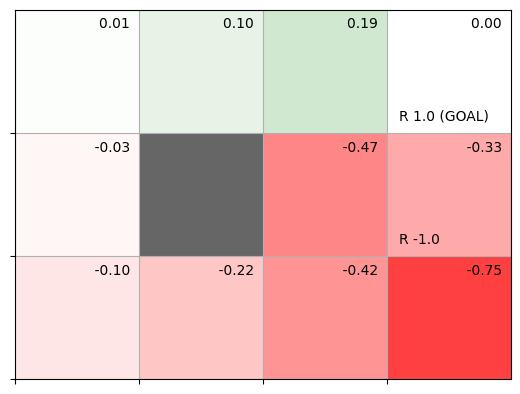

In [ ]:
from common.gridworld import GridWorld
from mc_eval import *

env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.eval()
            break

        state = next_state

env.render_v(agent.V) 

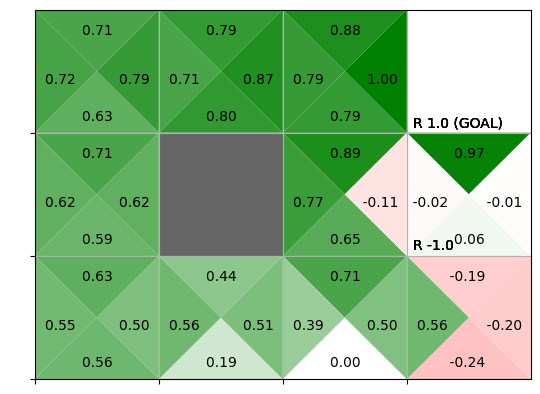

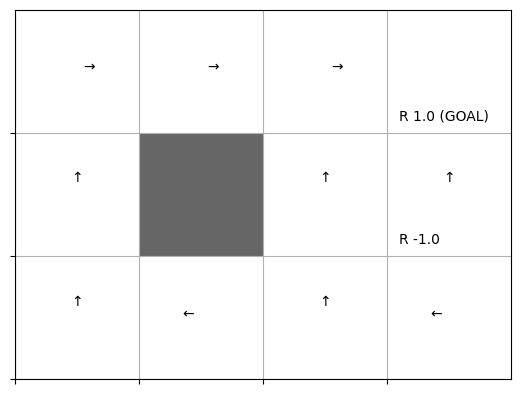

In [2]:
# 修正版のMcAgentクラスを使ってみる。
import sys, os
sys.path.append(os.pardir)
from mc_eval import *
from common.gridworld import *

env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)